In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
dl_models = glob('./models_dl/*.csv')

In [3]:
dl_models

['./models_dl/none_LSTM_best_lb24_H128_L2_bi1_dr0.0_ep200_lr0.0005.csv',
 './models_dl/none_ANN_best_lb24_h256-128_dp0.1_ep200_lr0.0005_wd1e-05_relu.csv',
 './models_dl/none_CNN_best_lb24_ch64-128_k5_s1_avg_ep200_lr0.0005.csv',
 './models_dl/physics_RNN_best_lb24_H128_L2_bi1_dr0.0_ep200_lr0.0005.csv',
 './models_dl/physics_ANN_best_lb24_h128-64_dp0.0_ep200_lr0.001_wd0.0_relu.csv',
 './models_dl/none_GRU_best_lb24_H128_L2_bi1_dr0.1_ep200_lr0.0005.csv',
 './models_dl/physics_GRU_best_lb24_H64_L2_bi0_dr0.1_ep200_lr0.0005.csv',
 './models_dl/physics_CNN_best_lb24_ch64-128_k5_s1_max_ep200_lr0.0005.csv',
 './models_dl/none_RNN_best_lb24_H128_L1_bi0_dr0.1_ep200_lr0.0001.csv',
 './models_dl/physics_LSTM_best_lb24_H64_L2_bi1_dr0.1_ep200_lr0.0005.csv']

In [4]:
dl_model_results = {}
dl_model_results['none'] = {}
dl_model_results['physics'] = {}
for model in dl_models:
    physics_check = model.split('/')[2].split('_')[0]
    model_name = model.split('/')[2].split('_')[1]
    one = pd.read_csv(model)
    dl_model_results[physics_check][model_name] = one

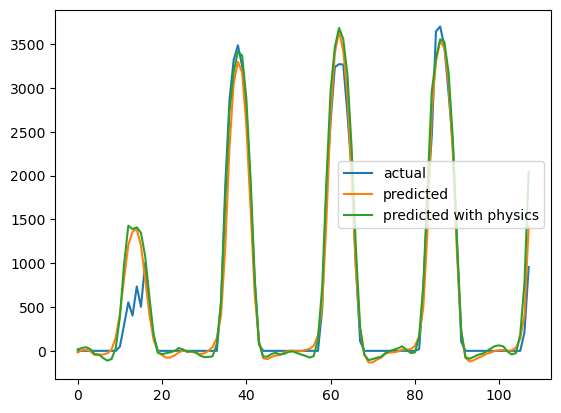

In [5]:
plt.plot(dl_model_results['none']['LSTM']['y_true'][:108], label = 'actual')
plt.plot(dl_model_results['none']['LSTM']['y_pred'][:108], label = 'predicted')
plt.plot(dl_model_results['physics']['LSTM']['y_pred'][:108], label = 'predicted with physics')
plt.legend()
plt.show()

In [13]:
ml_none_results = pd.read_pickle('./ML_preds_none_by_model.pkl')
ml_physics_results = pd.read_pickle('./ML_preds_phys_by_model.pkl')

In [16]:
len(ml_none_results['LightGBM'])

2328

In [17]:
dl_model_results['none']['LSTM']['y_true']

0         0.000026
1         0.000026
2         0.000026
3         0.000026
4         0.000026
           ...    
2300    144.000030
2301      0.000026
2302      0.000026
2303      0.000026
2304      0.000026
Name: y_true, Length: 2305, dtype: float64

In [ ]:
r2_score_dict = {}
mae_score_dict = {}
rmse_score_dict = {}



In [11]:
r2_score(dl_model_results['none']['LSTM']['y_true'], dl_model_results['none']['LSTM']['y_pred'])

0.9203221414624194